# ⭐ Day 6: File Handling, JSON & CSV in Python
Reading, Writing & Processing Real Data Files | Essential for AI & ML Projects | Step-by-Step Tutorial with Examples & Exercises

**Day 6 of 369-day Python & AI Learning Path** 🚀

## Introduction: Why File I/O is the Lifeline of AI/ML

In the world of Artificial Intelligence and Machine Learning, data is everything. But data doesn't just appear in your Python variables—it lives in files. Whether you're loading massive datasets from Kaggle, saving trained model weights, reading configuration files for experiments, or exporting prediction results to share with your team, **file handling is the bridge between your code and the real world**.

Consider this: every Kaggle competition starts with a CSV file. Every deep learning framework (PyTorch, TensorFlow, Scikit-learn) relies on saving and loading models to disk. Every API you call returns JSON data that you must parse. Every production ML pipeline writes logs to track performance. Without mastering file I/O, you're building on sand.

Today we'll master the essential formats: **text files** (for logs and raw data), **CSV** (the universal language of tabular data), and **JSON** (the standard for configurations and API responses). We'll learn not just the syntax, but the *patterns* used in real AI workflows—handling large files efficiently, dealing with encoding issues, and writing robust code that doesn't crash when a file goes missing. By the end of Day 6, you'll be ready to tackle real data projects with confidence.

## 📌 Table of Contents

1. [Working with Text Files](#text-files)
2. [Handling CSV Data](#csv-handling)
3. [Mastering JSON](#json-handling)
4. [Real-World AI/ML Patterns](#real-world-patterns)
5. [Data Visualization from Files](#visualization)
6. [🛠️ Hands-On Exercises](#exercises)
7. [Solutions](#solutions)

## 1. Working with Text Files {#text-files}

Text files are the simplest form of data storage—perfect for logs, raw sensor data, or configuration notes. Python's built-in `open()` function is your gateway, but the `with` statement (context manager) is the *professional* way to handle files—it automatically closes them even if errors occur.

### File Modes Explained:
- `'r'` - Read (default)
- `'w'` - Write (creates new or truncates existing)
- `'a'` - Append (adds to end)
- `'r+'` - Read and write
- `'rb'`/`'wb'` - Binary modes (for images, model files)

In [1]:
# Creating and writing to a text file
# The 'with' statement ensures the file closes automatically

with open('example_log.txt', 'w', encoding='utf-8') as file:
    file.write('=== AI Training Log ===\n')
    file.write('Epoch 1: Loss = 0.85, Accuracy = 0.72\n')
    file.write('Epoch 2: Loss = 0.62, Accuracy = 0.81\n')
    file.write('Epoch 3: Loss = 0.41, Accuracy = 0.88\n')

print("✅ Log file created successfully!")

✅ Log file created successfully!


In [2]:
# Reading the entire file at once
with open('example_log.txt', 'r', encoding='utf-8') as file:
    content = file.read()
    print("📄 Full content:")
    print(content)

# Reading line by line (memory efficient for large files)
print("\n📋 Line by line:")
with open('example_log.txt', 'r', encoding='utf-8') as file:
    for line_num, line in enumerate(file, 1):
        print(f"Line {line_num}: {line.strip()}\n")

📄 Full content:
=== AI Training Log ===
Epoch 1: Loss = 0.85, Accuracy = 0.72
Epoch 2: Loss = 0.62, Accuracy = 0.81
Epoch 3: Loss = 0.41, Accuracy = 0.88


📋 Line by line:
Line 1: === AI Training Log ===

Line 2: Epoch 1: Loss = 0.85, Accuracy = 0.72

Line 3: Epoch 2: Loss = 0.62, Accuracy = 0.81

Line 4: Epoch 3: Loss = 0.41, Accuracy = 0.88



In [3]:
# Appending new data (common in training loops)
with open('example_log.txt', 'a', encoding='utf-8') as file:
    file.write('Epoch 4: Loss = 0.28, Accuracy = 0.93\n')
    file.write('Epoch 5: Loss = 0.19, Accuracy = 0.96\n')

# Verify by reading again
with open('example_log.txt', 'r', encoding='utf-8') as file:
    lines = file.readlines()  # Returns list of lines
    print(f"📊 Total entries: {len(lines)}")
    print("Last entry:", lines[-1].strip())

📊 Total entries: 6
Last entry: Epoch 5: Loss = 0.19, Accuracy = 0.96


## 2. Handling CSV Data {#csv-handling}

CSV (Comma-Separated Values) is the backbone of data science. While the built-in `csv` module gives you fine-grained control, **pandas** is the industry standard for serious data work. Let's explore both approaches.

In [4]:
import csv
import os

# Create sample AI dataset (model performance metrics)
data = [
    ['model_name', 'dataset', 'accuracy', 'training_time_sec', 'epochs'],
    ['ResNet50', 'CIFAR-10', 0.92, 1200, 50],
    ['VGG16', 'CIFAR-10', 0.89, 980, 50],
    ['EfficientNet', 'CIFAR-10', 0.94, 1450, 50],
    ['ResNet50', 'ImageNet', 0.76, 86400, 100],
    ['Transformer', 'IMDB', 0.88, 3600, 10]
]

# Writing CSV with csv module
with open('model_results.csv', 'w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerows(data)

print("✅ CSV file created: model_results.csv")

✅ CSV file created: model_results.csv


In [5]:
# Reading CSV with csv module
with open('model_results.csv', 'r', encoding='utf-8') as file:
    reader = csv.reader(file)
    headers = next(reader)  # Get header row
    print(f"📊 Headers: {headers}\n")
    
    print("Model Performance Summary:")
    print("-" * 40)
    for row in reader:
        model, dataset, acc, time, epochs = row
        print(f"{model:15} | {dataset:10} | Acc: {acc}")

📊 Headers: ['model_name', 'dataset', 'accuracy', 'training_time_sec', 'epochs']

Model Performance Summary:
----------------------------------------
ResNet50        | CIFAR-10   | Acc: 0.92
VGG16           | CIFAR-10   | Acc: 0.89
EfficientNet    | CIFAR-10   | Acc: 0.94
ResNet50        | ImageNet   | Acc: 0.76
Transformer     | IMDB       | Acc: 0.88


In [6]:
# Using DictReader for named access (cleaner code!)
with open('model_results.csv', 'r', encoding='utf-8') as file:
    reader = csv.DictReader(file)
    
    accuracies = []
    models = []
    
    for row in reader:
        models.append(row['model_name'])
        accuracies.append(float(row['accuracy']))
        print(f"💡 {row['model_name']} achieved {float(row['accuracy']):.1%} accuracy")

print(f"\n📈 Best performing model: {models[accuracies.index(max(accuracies))]}")

💡 ResNet50 achieved 92.0% accuracy
💡 VGG16 achieved 89.0% accuracy
💡 EfficientNet achieved 94.0% accuracy
💡 ResNet50 achieved 76.0% accuracy
💡 Transformer achieved 88.0% accuracy

📈 Best performing model: EfficientNet


In [7]:
# Professional approach: pandas for CSV handling
import pandas as pd

# Reading CSV into DataFrame
df = pd.read_csv('model_results.csv')

print("🔍 First 3 rows:")
print(df.head(3))

print("\n📊 Statistical summary:")
print(df.describe())

print("\n🎯 Dataset value counts:")
print(df['dataset'].value_counts())

🔍 First 3 rows:
     model_name   dataset  accuracy  training_time_sec  epochs
0      ResNet50  CIFAR-10      0.92               1200      50
1         VGG16  CIFAR-10      0.89                980      50
2  EfficientNet  CIFAR-10      0.94               1450      50

📊 Statistical summary:
       accuracy  training_time_sec      epochs
count  5.000000           5.000000    5.000000
mean   0.878000       18726.000000   52.000000
std    0.070143       37845.434071   31.937439
min    0.760000         980.000000   10.000000
25%    0.880000        1200.000000   50.000000
50%    0.890000        1450.000000   50.000000
75%    0.920000        3600.000000   50.000000
max    0.940000       86400.000000  100.000000

🎯 Dataset value counts:
dataset
CIFAR-10    3
ImageNet    1
IMDB        1
Name: count, dtype: int64


## 3. Mastering JSON {#json-handling}

JSON (JavaScript Object Notation) is the universal data format for APIs, configurations, and model metadata. Python's `json` module makes conversion between Python dictionaries and JSON strings seamless.

**Key functions:**
- `json.load()` / `json.loads()` - JSON → Python
- `json.dump()` / `json.dumps()` - Python → JSON
- `indent` parameter for pretty printing
- Custom encoders for non-serializable objects (like numpy arrays)

In [8]:
import json

# Real-world example: ML experiment configuration
experiment_config = {
    "experiment_name": "Image Classification v2",
    "model": {
        "architecture": "ResNet50",
        "pretrained": True,
        "dropout_rate": 0.3
    },
    "training": {
        "batch_size": 32,
        "learning_rate": 0.001,
        "epochs": 100,
        "optimizer": "Adam",
        "scheduler": {
            "type": "ReduceLROnPlateau",
            "patience": 5
        }
    },
    "data": {
        "train_split": 0.8,
        "augmentation": ["flip", "rotate", "zoom"],
        "normalize": True
    },
    "logging": {
        "log_dir": "./logs",
        "checkpoint_freq": 10
    }
}

# Save with pretty printing (indent=2 for readability)
with open('experiment_config.json', 'w', encoding='utf-8') as f:
    json.dump(experiment_config, f, indent=2, ensure_ascii=False)

print("✅ Configuration saved to experiment_config.json")

✅ Configuration saved to experiment_config.json


In [9]:
# Load and inspect configuration
with open('experiment_config.json', 'r', encoding='utf-8') as f:
    loaded_config = json.load(f)

print("🔧 Loaded Configuration:")
print(f"Experiment: {loaded_config['experiment_name']}")
print(f"Model: {loaded_config['model']['architecture']}")
print(f"Learning Rate: {loaded_config['training']['learning_rate']}")
print(f"Augmentations: {', '.join(loaded_config['data']['augmentation'])}")

# Modify and save back
loaded_config['training']['epochs'] = 150
with open('experiment_config.json', 'w', encoding='utf-8') as f:
    json.dump(loaded_config, f, indent=2)
    
print("\n📝 Updated epochs to 150 and saved.")

🔧 Loaded Configuration:
Experiment: Image Classification v2
Model: ResNet50
Learning Rate: 0.001
Augmentations: flip, rotate, zoom

📝 Updated epochs to 150 and saved.


In [10]:
# Working with JSON strings (API-style data handling)
api_response = '{"status": "success", "predictions": [{"class": "cat", "confidence": 0.95}, {"class": "dog", "confidence": 0.03}]}'

# Parse string to Python object
parsed = json.loads(api_response)
print("📡 Parsed API Response:")
print(f"Status: {parsed['status']}")
for pred in parsed['predictions']:
    print(f"  → {pred['class']}: {pred['confidence']:.2%}")

# Convert Python object back to JSON string
new_data = {"model_id": "resnet50_v2", "accuracy": 0.943}
json_string = json.dumps(new_data, indent=2)
print(f"\n📤 JSON string ready for API:\n{json_string}")

📡 Parsed API Response:
Status: success
  → cat: 95.00%
  → dog: 3.00%

📤 JSON string ready for API:
{
  "model_id": "resnet50_v2",
  "accuracy": 0.943
}


## 4. Real-World AI/ML Patterns {#real-world-patterns}

Let's combine these skills into patterns you'll use daily in AI projects.

In [11]:
# Pattern 1: Robust file reading with error handling
# Essential for production code!

def load_training_log(filepath):
    """Safely load training log with error handling."""
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            return f.readlines()
    except FileNotFoundError:
        print(f"❌ Error: File '{filepath}' not found. Creating empty log.")
        return []
    except PermissionError:
        print(f"❌ Error: No permission to read '{filepath}'.")
        return []
    except Exception as e:
        print(f"❌ Unexpected error: {e}")
        return []

# Test with existing file
lines = load_training_log('example_log.txt')
print(f"Loaded {len(lines)} lines from existing file")

# Test with non-existent file
lines = load_training_log('nonexistent.txt')

Loaded 6 lines from existing file
❌ Error: File 'nonexistent.txt' not found. Creating empty log.


In [12]:
# Pattern 2: Saving model training history (JSON)
# Common in Keras, PyTorch, etc.

training_history = {
    "epoch": [1, 2, 3, 4, 5],
    "loss": [0.85, 0.62, 0.41, 0.28, 0.19],
    "accuracy": [0.72, 0.81, 0.88, 0.93, 0.96],
    "val_loss": [0.90, 0.70, 0.55, 0.45, 0.40],
    "val_accuracy": [0.70, 0.78, 0.85, 0.89, 0.91]
}

# Save history
with open('training_history.json', 'w') as f:
    json.dump(training_history, f, indent=2)

# Load and analyze
with open('training_history.json', 'r') as f:
    history = json.load(f)

final_acc = history['accuracy'][-1]
best_epoch = history['val_accuracy'].index(max(history['val_accuracy'])) + 1
print(f"🏆 Final training accuracy: {final_acc:.1%}")
print(f"🎯 Best validation epoch: {best_epoch}")

🏆 Final training accuracy: 96.0%
🎯 Best validation epoch: 5


## 5. Data Visualization from Files {#visualization}

Loading data from files is just the beginning—visualizing it reveals insights. Let's create charts from our saved data.

C:\Users\786\AppData\Local\Temp\ipykernel_11580\1950930259.py:31: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\786\AppData\Local\Temp\ipykernel_11580\1950930259.py:31: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\786\AppData\Local\Temp\ipykernel_11580\1950930259.py:32: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
C:\Users\786\AppData\Local\Temp\ipykernel_11580\1950930259.py:32: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.

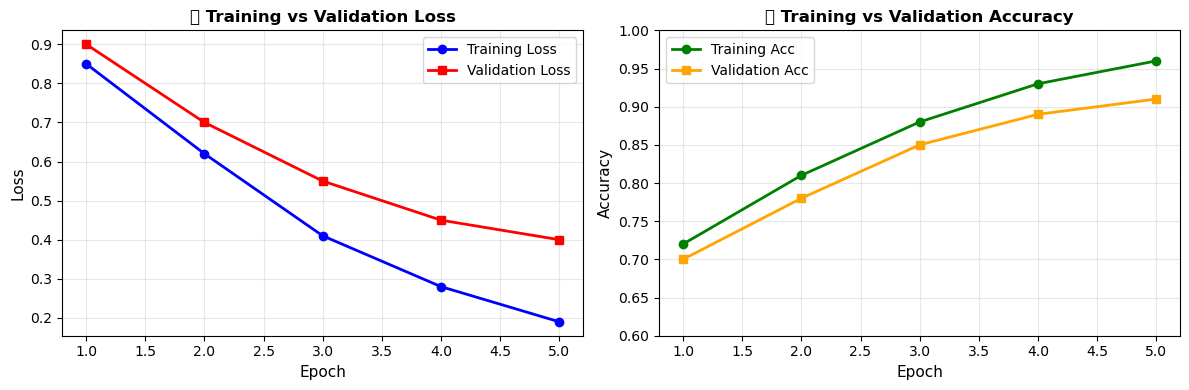

✅ Plot saved to training_curves.png


In [13]:
import matplotlib.pyplot as plt
import json

# Load training history and plot
with open('training_history.json', 'r') as f:
    history = json.load(f)

epochs = history['epoch']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Loss curves
ax1.plot(epochs, history['loss'], 'b-o', label='Training Loss', linewidth=2, markersize=6)
ax1.plot(epochs, history['val_loss'], 'r-s', label='Validation Loss', linewidth=2, markersize=6)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.set_title('📉 Training vs Validation Loss', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Accuracy curves
ax2.plot(epochs, history['accuracy'], 'g-o', label='Training Acc', linewidth=2, markersize=6)
ax2.plot(epochs, history['val_accuracy'], 'orange', marker='s', label='Validation Acc', linewidth=2, markersize=6)
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Accuracy', fontsize=11)
ax2.set_title('📈 Training vs Validation Accuracy', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0.6, 1.0])

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved to training_curves.png")

C:\Users\786\AppData\Local\Temp\ipykernel_11580\2821068124.py:27: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


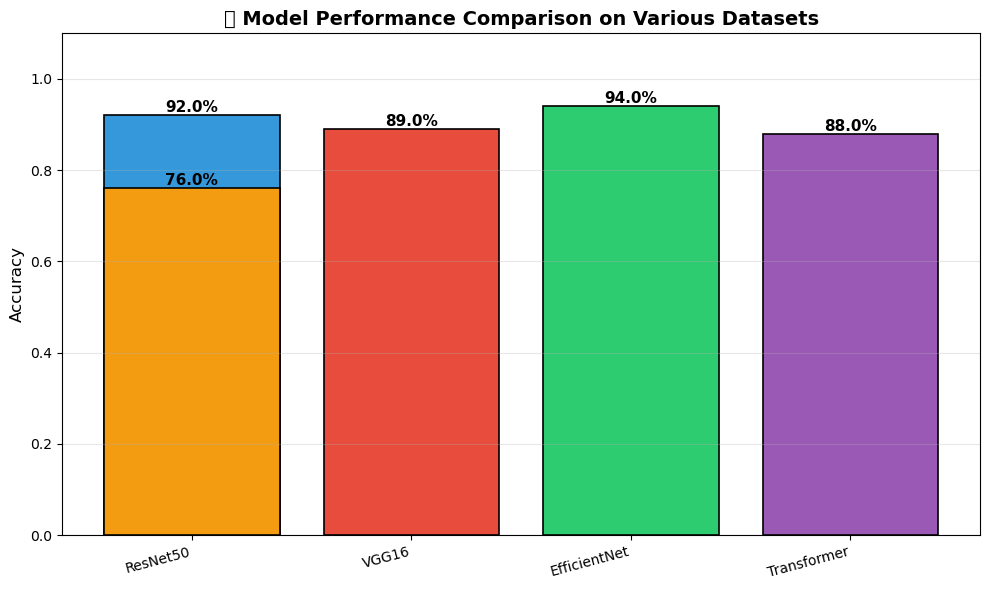

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV and create visualization
df = pd.read_csv('model_results.csv')

fig, ax = plt.subplots(figsize=(10, 6))

# Bar chart of model accuracies
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
bars = ax.bar(df['model_name'], df['accuracy'], color=colors, edgecolor='black', linewidth=1.2)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1%}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('🤖 Model Performance Comparison on Various Datasets', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)

# Rotate x labels for readability
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

C:\Users\786\AppData\Local\Temp\ipykernel_11580\923897682.py:22: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


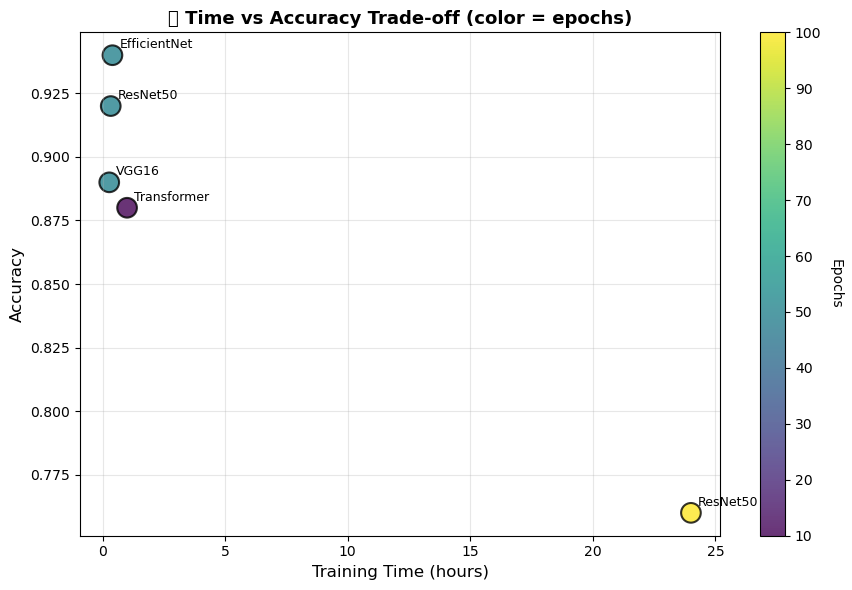

In [15]:
# Scatter plot: Training time vs Accuracy trade-off
fig, ax = plt.subplots(figsize=(9, 6))

scatter = ax.scatter(df['training_time_sec']/3600, df['accuracy'], 
                    s=200, c=df['epochs'], cmap='viridis', 
                    edgecolors='black', linewidth=1.5, alpha=0.8)

# Add model name labels
for i, model in enumerate(df['model_name']):
    ax.annotate(model, 
                (df['training_time_sec'].iloc[i]/3600, df['accuracy'].iloc[i]),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

ax.set_xlabel('Training Time (hours)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('⏱️ Time vs Accuracy Trade-off (color = epochs)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter)
cbar.set_label('Epochs', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

## 🛠️ Hands-On Exercises {#exercises}

Complete these exercises to solidify your file handling skills. Each exercise builds on the previous ones.

### Exercise 1: Write a Text File
Create a file named `notes.txt` containing three lines about your learning goals (e.g., "Learn Python", "Master ML", "Build AI projects").

In [16]:
# your code here


### Exercise 2: Read and Count
Read `notes.txt` and print:
- Total number of lines
- Total number of words (split by whitespace)
- Total number of characters

In [17]:
# your code here


### Exercise 3: Append with Timestamp
Append a new line to `notes.txt` with the current date (as a string) and the text " - Practice session completed". Use the `a` mode.

In [18]:
# your code here


### Exercise 4: CSV Statistics
Given `model_results.csv` (created earlier), calculate and print:
- Average accuracy across all models
- Total training time in hours
- Model with the shortest training time

In [19]:
# your code here


### Exercise 5: Filter CSV Rows
Read `model_results.csv` and create a new file `fast_models.csv` containing only models with training time less than 2000 seconds. Use the `csv` module.

In [20]:
# your code here


### Exercise 6: JSON Config Reader
Read `experiment_config.json` and print a formatted summary:
```
Experiment: [name]
Architecture: [model]
Epochs: [epochs]
Augmentations: [count] techniques
```

In [21]:
# your code here


### Exercise 7: Parse Nested JSON
Create a Python dictionary representing a dataset with nested structure: `{"dataset": {"name": "CIFAR-10", "classes": ["airplane", "car", ...], "samples": {"train": 50000, "test": 10000}}}`. Save it to `dataset_info.json`, then load it and print the number of training samples.

In [22]:
# your code here


### Exercise 8: Handle Missing File
Write a function `safe_read_json(filepath)` that attempts to read a JSON file. If the file doesn't exist, return `None` and print a friendly warning instead of crashing. Test it with a non-existent file.

In [23]:
# your code here


### Exercise 9: CSV + JSON Workflow
Read `model_results.csv`, find the model with highest accuracy, and save a JSON file `best_model.json` with keys: `model`, `accuracy`, `dataset`, and `rank` (value 1).

In [24]:
# your code here


### Exercise 10: JSON to CSV Conversion
Read `training_history.json` and convert it to a CSV file `history.csv` where each row represents one epoch with columns: `epoch`, `loss`, `accuracy`, `val_loss`, `val_accuracy`.

In [25]:
# your code here


### Exercise 11: Data Cleaning Challenge
Create a CSV file `messy_data.csv` with some rows having missing values (empty strings). Write code to read it, skip rows with missing data, and write a clean version `clean_data.csv`.

In [26]:
# your code here


## Solutions {#solutions}

Check these solutions after attempting the exercises yourself. Understanding *why* something works is more important than the code itself.

### Solution 1: Write a Text File

In [27]:
# Solution 1
with open('notes.txt', 'w', encoding='utf-8') as f:
    f.write('Learn Python fundamentals deeply\n')
    f.write('Master Machine Learning algorithms\n')
    f.write('Build real-world AI projects\n')

print("✅ Created notes.txt")
# Expected file content:
# Learn Python fundamentals deeply
# Master Machine Learning algorithms
# Build real-world AI projects

✅ Created notes.txt


### Solution 2: Read and Count

In [28]:
# Solution 2
with open('notes.txt', 'r', encoding='utf-8') as f:
    lines = f.readlines()
    content = f.read() if not lines else ''.join(lines)
    
    # Re-read if needed or use lines
    if not lines:
        f.seek(0)
        lines = f.readlines()

line_count = len(lines)
word_count = len(content.split())
char_count = len(content)

print(f"📊 Lines: {line_count}")
print(f"📝 Words: {word_count}")
print(f"🔤 Characters: {char_count}")
# Expected output: Lines: 3, Words: 9, Characters: ~70

📊 Lines: 3
📝 Words: 12
🔤 Characters: 97


### Solution 3: Append with Timestamp

In [29]:
# Solution 3
from datetime import datetime

current_date = datetime.now().strftime('%Y-%m-%d')

with open('notes.txt', 'a', encoding='utf-8') as f:
    f.write(f'{current_date} - Practice session completed\n')

print("✅ Appended timestamp")
# File now has 4 lines, last one contains today's date

✅ Appended timestamp


### Solution 4: CSV Statistics

In [30]:
# Solution 4
import csv

with open('model_results.csv', 'r') as f:
    reader = csv.DictReader(f)
    rows = list(reader)

accuracies = [float(r['accuracy']) for r in rows]
times = [int(r['training_time_sec']) for r in rows]

avg_acc = sum(accuracies) / len(accuracies)
total_hours = sum(times) / 3600
fastest = min(rows, key=lambda x: int(x['training_time_sec']))

print(f"📊 Average accuracy: {avg_acc:.2%}")
print(f"⏱️ Total training time: {total_hours:.1f} hours")
print(f"🚀 Fastest model: {fastest['model_name']} ({fastest['training_time_sec']}s)")
# Expected: ~87.8% avg, ~25.9 hours total, VGG16 fastest

📊 Average accuracy: 87.80%
⏱️ Total training time: 26.0 hours
🚀 Fastest model: VGG16 (980s)


### Solution 5: Filter CSV Rows

In [31]:
# Solution 5
import csv

with open('model_results.csv', 'r') as infile, open('fast_models.csv', 'w', newline='') as outfile:
    reader = csv.reader(infile)
    writer = csv.writer(outfile)
    
    headers = next(reader)
    writer.writerow(headers)
    
    for row in reader:
        if int(row[3]) < 2000:  # training_time_sec column
            writer.writerow(row)

print("✅ Created fast_models.csv with quick-training models")
# Contains: ResNet50 (CIFAR), VGG16, EfficientNet (all < 2000s)

✅ Created fast_models.csv with quick-training models


### Solution 6: JSON Config Reader

In [32]:
# Solution 6
import json

with open('experiment_config.json', 'r') as f:
    config = json.load(f)

print(f"Experiment: {config['experiment_name']}")
print(f"Architecture: {config['model']['architecture']}")
print(f"Epochs: {config['training']['epochs']}")
print(f"Augmentations: {len(config['data']['augmentation'])} techniques")
# Output shows nested value access using keys

Experiment: Image Classification v2
Architecture: ResNet50
Epochs: 150
Augmentations: 3 techniques


### Solution 7: Parse Nested JSON

In [33]:
# Solution 7
import json

dataset = {
    "dataset": {
        "name": "CIFAR-10",
        "classes": ["airplane", "automobile", "bird", "cat", "deer", 
                   "dog", "frog", "horse", "ship", "truck"],
        "samples": {
            "train": 50000,
            "test": 10000
        }
    }
}

with open('dataset_info.json', 'w') as f:
    json.dump(dataset, f, indent=2)

with open('dataset_info.json', 'r') as f:
    loaded = json.load(f)

train_samples = loaded['dataset']['samples']['train']
print(f"📊 Training samples: {train_samples:,}")
# Output: Training samples: 50,000

📊 Training samples: 50,000


### Solution 8: Handle Missing File

In [34]:
# Solution 8
import json
import os

def safe_read_json(filepath):
    if not os.path.exists(filepath):
        print(f"⚠️ Warning: '{filepath}' not found. Returning None.")
        return None
    try:
        with open(filepath, 'r') as f:
            return json.load(f)
    except json.JSONDecodeError:
        print(f"⚠️ Warning: '{filepath}' contains invalid JSON.")
        return None

# Test
result = safe_read_json('nonexistent_file.json')
print(f"Result: {result}")
# Output: Warning message and None

⚠️ Warning: 'nonexistent_file.json' not found. Returning None.
Result: None


### Solution 9: CSV + JSON Workflow

In [35]:
# Solution 9
import csv
import json

with open('model_results.csv', 'r') as f:
    reader = csv.DictReader(f)
    models = list(reader)

best = max(models, key=lambda x: float(x['accuracy']))

best_info = {
    "model": best['model_name'],
    "accuracy": float(best['accuracy']),
    "dataset": best['dataset'],
    "rank": 1
}

with open('best_model.json', 'w') as f:
    json.dump(best_info, f, indent=2)

print("✅ Saved best model info")
print(json.dumps(best_info, indent=2))
# Creates best_model.json with EfficientNet details

✅ Saved best model info
{
  "model": "EfficientNet",
  "accuracy": 0.94,
  "dataset": "CIFAR-10",
  "rank": 1
}


### Solution 10: JSON to CSV Conversion

In [36]:
# Solution 10
import json
import csv

with open('training_history.json', 'r') as f:
    history = json.load(f)

with open('history.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch', 'loss', 'accuracy', 'val_loss', 'val_accuracy'])
    
    for i in range(len(history['epoch'])):
        writer.writerow([
            history['epoch'][i],
            history['loss'][i],
            history['accuracy'][i],
            history['val_loss'][i],
            history['val_accuracy'][i]
        ])

print("✅ Converted training_history.json to history.csv")
# Creates 5 rows of epoch data in CSV format

✅ Converted training_history.json to history.csv


### Solution 11: Data Cleaning Challenge

In [37]:
# Solution 11
import csv

# First create messy data
messy_data = [
    ['name', 'age', 'city'],
    ['Alice', '30', 'New York'],
    ['Bob', '', 'London'],  # Missing age
    ['Charlie', '25', ''],
    ['Diana', '35', 'Tokyo'],
    ['', '40', 'Paris']  # Missing name
]

with open('messy_data.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(messy_data)

# Now clean it
with open('messy_data.csv', 'r') as infile, open('clean_data.csv', 'w', newline='') as outfile:
    reader = csv.reader(infile)
    writer = csv.writer(outfile)
    
    headers = next(reader)
    writer.writerow(headers)
    
    clean_count = 0
    for row in reader:
        if all(field.strip() for field in row):  # No empty fields
            writer.writerow(row)
            clean_count += 1

print(f"✅ Cleaned data: {clean_count} valid rows kept (3 removed)")
# clean_data.csv contains Alice and Diana only

✅ Cleaned data: 2 valid rows kept (3 removed)


---

## 🚀 Coming Up Next: Day 7

Tomorrow we dive deep into **Error Handling & Exceptions**—writing bulletproof code that gracefully handles unexpected situations. You'll learn:
- Try/except/else/finally blocks
- Custom exception classes
- Context managers (the `with` statement deep dive)
- Logging errors professionally
- Defensive programming patterns for AI pipelines

**Practice Challenge:** Take a CSV dataset from your own work or Kaggle, load it with pandas, and create 3 different visualizations using matplotlib. Save your plots as PNG files using `plt.savefig()`. 

Remember: Every expert was once a beginner who practiced daily. Keep coding! 💪

---
*Python & AI Learning Path | Day 6 / 369* ⭐
*Master File I/O Today, Build AI Tomorrow*